# The degrading battery: a reproducible solution

**Day 1 net: $16,137.01 per battery**, versus $14,505.46 for Amp's LP.
The feasible schedule is within $0.001 of a numerical global upper bound.
All seven nominal days are solved to the same standard.

| Day | Amp LP net | Rainflow net | Improvement | Numerical gap |
|---:|---:|---:|---:|---:|
| 1 | $14,505.46 | $16,137.01 | $1,631.56 | $0.000151 |
| 2 | $12,177.83 | $12,584.69 | $406.86 | $0.000099 |
| 3 | $15,067.53 | $15,816.60 | $749.08 | $0.000129 |
| 4 | $7,941.42 | $9,087.04 | $1,145.62 | $0.000086 |
| 5 | $14,923.31 | $16,272.93 | $1,349.62 | $0.000242 |
| 6 | $11,790.56 | $13,286.22 | $1,495.66 | $0.000094 |
| 7 | $14,932.47 | $16,002.97 | $1,070.50 | $0.000088 |


Seven-day total per battery: **$99,187.47**, versus **$91,338.57**.
With 12 batteries and these seven days treated as representative, annual net operating profit is
**$62,063,015.00**, versus **$57,151,849.08**;
the improvement is **$4,911,165.91**.

Run the cells in order. The source data, scoring functions, stored schedules, solver,
and sensitivity checks are embedded; no network download is required.
Dependencies: Python, NumPy, SciPy >= 1.9 (HiGHS), and Matplotlib.
`SCHEDULES[1]` through `SCHEDULES[7]` give the 49 SOC boundaries.

Source: the [puzzle notebook](https://colab.research.google.com/drive/1WWEgG3tyQ5Ybo_3kjfQHYgMwJg6po9Qz),
also supplied as a pasted attachment. Prices and scoring are reproduced unchanged.


## Model and numerical global bound

For slot $t$, let $u_t,v_t\ge0$ be the SOC increase/decrease in MWh:

$$s_{t+1}=s_t+u_t-v_t,\quad 0\le u_t\le23.75,\quad0\le v_t\le25/0.95.$$

The objective is to maximize

$$\sum_t p_t(0.95v_t-u_t/0.95)-W_\beta(s),\qquad
W_\beta(s)=3000\sum_{(r,c)\in\operatorname{RF}(s)}c(r/100)^\beta.$$

SOC stays in [0,100] and starts/ends at 50. For negative-price slots, a binary mode
enforces $u_tv_t=0$. For nonnegative prices, simultaneous cycling can be removed
without lowering cash flow or changing SOC, so no binary is needed there.

Rainflow cost with convex increasing depth stress is convex in the SOC path
([Shi et al., 2017](https://arxiv.org/abs/1703.07968)). Each evaluated path provides
a supporting plane $w\ge W(s^k)+g_k^T(s-s^k)$. The resulting mixed-integer linear
master underestimates wear, so its dual bound gives a **global upper bound on profit**.
The original notebook's rainflow counter scores every candidate to obtain a lower bound.
The algorithm stops when the bounds meet to the requested tolerance.

These are numerical optimization certificates, subject to floating-point and solver
tolerances. Stored schedules have been moved an imperceptible distance toward flat
SOC to remove numerical feasibility violations. The reported gap is recomputed after
that adjustment. The source rainflow routine itself uses a 1e-9 reversal tolerance.

This is not a claim that the entire problem is an ordinary convex program: negative
prices make the cash-flow term nonconcave. The integer modes handle that issue.


## Original data and scoring code

In [ ]:
"""
THE DEGRADING BATTERY  --  everything you need to solve the puzzle in one file.

Copy this whole file into a Google Colab cell and run it. It contains
  * the prices for 7 days (48 half-hour slots each),
  * the battery data,
  * an exact rainflow counter and the wear formula,
  * score():  checks and scores ANY schedule you come up with,
  * lp_baseline():  Amp's current LP, so you know what to beat,
  * plot_day():  a quick picture.

Your job: pick the state of charge (SOC, in MWh) at the 49 slot boundaries of day 1
(soc[0] ... soc[48], soc[0] = soc[48] = 50) so that  net profit = cash flow - wear  is maximal.
Use any solver you like. Check your answer with

    score(1, my_soc)

Needs numpy and scipy (both are preinstalled in Colab); matplotlib is only used for plots.
"""
from collections import deque

import numpy as np

# =============================================================================
# Battery data
# =============================================================================
P_MAX = 50.0        # MW    power limit, charging and discharging (grid side)
CAP = 100.0         # MWh   usable energy window: 0 <= SOC <= 100
ETA_C = 0.95        # charging efficiency    (grid -> cell)
ETA_D = 0.95        # discharging efficiency (cell -> grid)
DT = 0.5            # h     length of a slot
T = 48              # slots per day
SOC0 = 50.0         # MWh   SOC at 00:00 and again at 24:00
BETA = 2.0          # wear exponent: cycles to failure at depth DoD = 6000 / DoD**BETA
C_FULL = 3000.0     # $     wear cost of one full-depth cycle ($18M pack / 6000 cycles)

MAX_UP = P_MAX * DT * ETA_C      # largest SOC increase in one slot  (23.75 MWh)
MAX_DOWN = P_MAX * DT / ETA_D    # largest SOC decrease in one slot  (26.32 MWh)

# =============================================================================
# Prices in $/MWh, 7 days x 48 half-hour slots (00:00-00:30, 00:30-01:00, ...).
# Day 1 is tomorrow; days 2-7 are for the extra credit.
# =============================================================================
PRICES = np.array([
    # day 1
    [
        32.66, 32.56, 16.34, 4.04, 24.47, 21.60, 40.35, 40.40, 10.79, 17.49, 14.15, 24.32,
        39.25, 60.13, 45.76, 40.19, 40.67, 24.39, 11.59, 105.17, 55.39, -18.98, -2.02,
        -24.09, -23.10, -12.87, -16.67, -2.76, 0.31, 17.37, 17.20, 70.79, 40.33, 47.29,
        57.49, 78.36, 103.47, 114.05, 131.83, 136.05, 127.52, 180.44, 81.74, 59.13, 64.17,
        68.12, 31.84, 59.19,
    ],
    # day 2
    [
        29.40, 35.93, 28.06, 43.57, 38.71, 47.19, 34.96, 0.97, 2.11, 7.46, 32.37, 41.50,
        49.40, 46.48, 59.28, 71.40, 55.84, 48.90, 8.89, 14.48, 1.62, 3.97, 4.74, -1.84,
        -6.21, 1.72, 2.47, -19.40, 10.93, 15.50, 5.41, 14.91, 43.94, 41.24, 86.25, 102.31,
        101.69, 116.63, 129.57, 110.50, 150.11, 76.43, 67.41, 117.31, 43.03, 36.85, 39.48,
        43.03,
    ],
    # day 3
    [
        37.56, 32.37, 37.14, 72.91, 35.84, 51.35, 32.36, 23.99, 46.82, 40.27, 22.03, 48.77,
        60.14, 77.97, 112.55, 83.78, 62.91, 55.37, 34.81, 15.94, -4.26, -6.83, -23.17,
        -8.52, -23.39, -17.25, -32.43, -8.27, 1.40, 14.52, 14.22, -0.55, 43.70, 47.25,
        77.07, 57.74, 71.32, 107.95, 132.07, 148.24, 135.49, 124.02, 117.08, 95.88, 91.66,
        81.85, 48.64, 48.83,
    ],
    # day 4
    [
        26.13, 31.44, 27.57, 48.35, 21.62, 3.77, 7.79, 12.99, 27.74, 30.18, 11.86, 22.06,
        106.03, 10.96, 40.90, 64.04, 54.88, 36.57, 26.53, 33.15, 2.78, 10.61, 10.74, 13.76,
        11.53, 18.75, 10.61, 8.18, 10.24, 24.45, 7.63, 25.10, 29.36, 71.57, 76.66, 79.72,
        81.10, 94.67, 86.38, 90.67, 77.12, 86.45, 88.56, 58.68, 61.83, 44.73, 47.29, 18.97,
    ],
    # day 5
    [
        34.30, 31.62, 42.59, 33.62, 25.35, 43.42, 32.87, 31.13, 11.13, 27.03, 109.55, 30.42,
        59.08, 60.40, 92.19, 104.23, 53.55, 53.51, 23.75, 32.10, 26.79, -19.92, -5.09,
        -5.15, -5.23, 3.56, -24.99, 11.74, 32.99, 32.78, 10.64, 65.02, 58.49, 77.05, 115.81,
        130.30, 153.75, 132.69, 136.35, 107.53, 99.82, 104.32, 54.90, 75.36, 44.93, 47.75,
        43.00, 55.31,
    ],
    # day 6
    [
        22.86, 28.30, 41.97, 29.68, 33.16, 91.65, 19.62, 23.79, 29.82, 94.21, 61.16, 51.27,
        34.73, 33.95, 40.31, 41.31, 25.16, 38.00, 3.21, -3.70, 4.10, -6.88, -30.44, 0.04,
        -19.96, 15.88, 12.88, -17.93, 12.84, 23.12, -11.23, 2.91, 39.60, 65.29, 27.53,
        43.40, 31.47, 38.95, 64.91, 67.21, 83.72, 86.11, 70.05, 74.08, 45.12, 125.42, 43.20,
        14.57,
    ],
    # day 7
    [
        31.03, 20.02, 16.66, 27.25, 34.41, 14.82, 14.59, 36.31, 22.16, 12.46, 34.46, 22.75,
        21.00, 47.22, 65.09, 67.78, 52.64, 51.82, 32.14, 17.90, -11.22, 23.91, 13.20, 9.12,
        22.69, 6.02, -26.94, -24.43, -8.53, -9.09, 21.46, 20.70, 40.00, 60.87, 75.88, 89.29,
        163.76, 101.66, 138.72, 125.85, 111.73, 82.73, 178.39, 95.58, 60.69, 62.10, 41.29,
        24.46,
    ],
])


def prices_for(day):
    """Prices of day 1..7 as an array of 48 values."""
    if not 1 <= day <= 7:
        raise ValueError("day must be between 1 and 7")
    return PRICES[day - 1]


# =============================================================================
# Rainflow counting (ASTM E1049) and the wear formula
# =============================================================================
def _reversals(series, tol=1e-9):
    """End points and turning points of a series (repeated values are dropped)."""
    s = [series[0]]
    for v in series[1:]:
        if abs(v - s[-1]) > tol:
            s.append(v)
    if len(s) < 3:
        return s
    out = [s[0]]
    for i in range(1, len(s) - 1):
        if (s[i] - s[i - 1]) * (s[i + 1] - s[i]) < 0:
            out.append(s[i])
    out.append(s[-1])
    return out


def rainflow_cycles(series):
    """Returns a list of (range, count) with count 1.0 (full cycle) or 0.5 (half cycle)."""
    pts, res = deque(), []
    for p in _reversals(list(series)):
        pts.append(p)
        while len(pts) >= 3:
            x = abs(pts[-2] - pts[-1])
            y = abs(pts[-3] - pts[-2])
            if x < y:
                break
            if len(pts) == 3:                        # Y contains the start point: half cycle
                res.append((y, 0.5))
                pts.popleft()
            else:                                    # closed cycle
                res.append((y, 1.0))
                last = pts.pop(); pts.pop(); pts.pop(); pts.append(last)
    pl = list(pts)
    for a, b in zip(pl, pl[1:]):                     # what is left counts as half cycles
        res.append((abs(a - b), 0.5))
    return res


def wear_cost(soc, beta=BETA):
    """Wear in $ of one day's SOC path (49 values): a cycle of range r costs C_FULL*(r/CAP)**beta."""
    return C_FULL * sum(c * (r / CAP) ** beta for r, c in rainflow_cycles(soc))


# =============================================================================
# Cash flow, feasibility, scoring
# =============================================================================
def revenue(day_prices, soc):
    """Cash flow in $: sell ETA_D*|D| MWh when the SOC drops by |D|, buy D/ETA_C MWh when it rises by D."""
    d = np.diff(np.asarray(soc, float))
    return float(np.sum(day_prices * (ETA_D * np.maximum(0, -d) - np.maximum(0, d) / ETA_C)))


def net_profit(day_prices, soc, beta=BETA):
    return revenue(day_prices, soc) - wear_cost(soc, beta)


def check_feasible(soc, tol=1e-6):
    """Returns a list of problems (empty list = feasible)."""
    soc = np.asarray(soc, float)
    if len(soc) != T + 1:
        return [f"need {T + 1} SOC values, got {len(soc)}"]
    d = np.diff(soc)
    problems = []
    if abs(soc[0] - SOC0) > tol or abs(soc[-1] - SOC0) > tol:
        problems.append("SOC must start and end at 50 MWh")
    if soc.min() < -tol or soc.max() > CAP + tol:
        problems.append("SOC must stay between 0 and 100 MWh")
    if d.max() > MAX_UP + tol:
        problems.append(f"charging too fast: at most +{MAX_UP:.2f} MWh per slot")
    if d.min() < -MAX_DOWN - tol:
        problems.append(f"discharging too fast: at most -{MAX_DOWN:.2f} MWh per slot")
    return problems


def lp_baseline(day_prices, adder=None):
    """Amp's LP: maximize cash flow minus a FLAT wear price per MWh sold.
    Default price = $3000 / (100 MWh * 0.95) = $31.58 per MWh. Returns the SOC path (49 values)."""
    from scipy.optimize import linprog
    if adder is None:
        adder = C_FULL / (CAP * ETA_D)
    n = T
    c = np.concatenate([day_prices * DT, -(day_prices - adder) * DT])   # x = [charge MW (n), discharge MW (n)]
    low = np.tril(np.ones((n, n)))
    a = np.hstack([DT * ETA_C * low, -DT / ETA_D * low])                # SOC after slot t = SOC0 + a @ x
    a_ub = np.vstack([a, -a])
    b_ub = np.concatenate([np.full(n, CAP - SOC0), np.full(n, SOC0)])
    a_eq = np.concatenate([DT * ETA_C * np.ones(n), -DT / ETA_D * np.ones(n)])[None, :]
    res = linprog(c, A_ub=a_ub, b_ub=b_ub, A_eq=a_eq, b_eq=[0.0], bounds=[(0, P_MAX)] * (2 * n), method="highs")
    soc = SOC0 + np.concatenate([[0.0], np.cumsum(DT * (ETA_C * res.x[:n] - res.x[n:] / ETA_D))])
    soc[-1] = SOC0
    return soc


def score(day, soc, label="your schedule"):
    """Checks and scores a schedule for the given day (1..7) and compares it with Amp's LP."""
    p = prices_for(day)
    lp = lp_baseline(p)
    for name, s in (("Amp's LP", lp), (label, soc)):
        problems = check_feasible(s)
        rev, wr = revenue(p, s), wear_cost(s)
        print(f"{name:>14}: cash flow ${rev:>9,.2f}   wear ${wr:>8,.2f}   NET ${rev - wr:>9,.2f}"
              + ("" if not problems else "   <-- INFEASIBLE: " + "; ".join(problems)))
    gain = net_profit(p, soc) - net_profit(p, lp)
    print(f"{'difference':>14}: ${gain:,.2f} per battery and day")


def plot_day(day, **schedules):
    """Prices and any number of schedules, e.g.  plot_day(1, lp=lp_baseline(prices_for(1)), mine=my_soc)"""
    import matplotlib.pyplot as plt
    p = prices_for(day)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
    for name, s in schedules.items():
        a1.plot(np.arange(T + 1) / 2, s, lw=2, label=name)
    a1.set_ylabel("state of charge [MWh]"); a1.set_ylim(-3, 105); a1.grid(alpha=.3)
    if schedules:
        a1.legend()
    a1.set_title(f"Day {day}")
    a2.bar(np.arange(T) / 2 + 0.25, p, width=0.5, color=["tab:blue" if v >= 0 else "tab:red" for v in p])
    a2.set_ylabel("price [$/MWh]"); a2.set_xlabel("hour of day"); a2.set_xlim(0, 24); a2.grid(alpha=.3)
    plt.tight_layout(); plt.show()


# =============================================================================
# Quick self-test (runs when you execute the file; delete if you like)
# =============================================================================


## Stored schedules and direct checks

All numbers below are SOC in MWh. Slot 0 is midnight; slot 48 is the following midnight.

In [2]:
import json
RESULTS = json.loads(r'''{
  "1.5": {
    "1": {
      "day": 1,
      "beta": 1.5,
      "soc": [
        50.0,
        43.028715344708395,
        43.02870533598401,
        43.028705336005,
        66.77870533598124,
        66.76640012352023,
        66.77869829433791,
        65.97277870652613,
        39.65698923286823,
        63.406989232844474,
        63.26383319931842,
        66.77870026376354,
        66.77870302160207,
        66.77870302160566,
        40.46291354794778,
        28.881585262577484,
        28.881585262577484,
        28.88157894742899,
        28.881578947389546,
        52.631578947365796,
        26.315789473707902,
        5.000799774279585e-11,
        23.750000000026255,
        17.0725074253239,
        40.822507425300145,
        64.57250742527638,
        76.24999755646644,
        99.99999755644268,
        99.99999999994999,
        99.99999999994999,
        99.99999999994999,
        99.99999999994999,
        76.24999822966444,
        99.99999822964068,
        99.99999999994999,
        99.99999999994999,
        99.99999999994999,
        99.99999999994999,
        99.99999999994999,
        73.68421052629209,
        47.3684210526342,
        26.315789473707902,
        5.000799774279585e-11,
        5.000799774279585e-11,
        23.750000000026255,
        23.750000000026255,
        23.463680273238754,
        47.213680273215,
        50.0
      ],
      "cash": 20701.84804525316,
      "wear": 5720.698771491346,
      "profit": 14981.149273761814,
      "upper_bound": 14981.14995751293,
      "gap": 0.0006837511155026732,
      "iterations": 194,
      "seconds": 6.562517404556274
    },
    "2": {
      "day": 2,
      "beta": 1.5,
      "soc": [
        50.0,
        50.00003150175031,
        48.95565362444803,
        50.000031353423545,
        34.571451925288855,
        34.592142038914574,
        8.276352565256701,
        8.27634953670541,
        32.02634953668164,
        55.77634953665787,
        79.52634953663411,
        79.52634953663457,
        79.52633561001738,
        78.94737113724587,
        78.94737113724587,
        52.63158166358799,
        26.315792189930114,
        2.7162722417983787e-06,
        5.0043524879583856e-11,
        0.9528221003624537,
        1.4596461674898364e-05,
        23.7500145964379,
        23.750014596440078,
        23.395678337445403,
        47.14567833742163,
        70.89567833739785,
        76.26658616990271,
        76.24999999398311,
        99.99999999395934,
        99.99999999994995,
        95.97534655073866,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        73.68421052629208,
        47.368421052634204,
        26.315789473707916,
        5.0043524879583856e-11,
        2.565789473731691,
        26.315789473707916,
        5.0043524879583856e-11,
        5.0043524879583856e-11,
        23.750000000026272,
        47.5000000000025,
        50.0
      ],
      "cash": 18064.523292657355,
      "wear": 6336.371597876331,
      "profit": 11728.151694781023,
      "upper_bound": 11728.152665994488,
      "gap": 0.0009712134651636006,
      "iterations": 257,
      "seconds": 1.5202956199645996
    },
    "3": {
      "day": 3,
      "beta": 1.5,
      "soc": [
        50.0,
        50.0,
        68.16536642094273,
        68.16538168684443,
        41.84959221318758,
        47.86847243419562,
        41.84958680586545,
        41.849586805915514,
        65.59958680589082,
        55.19740385671004,
        55.19736911279577,
        78.94736911277107,
        78.94736842102253,
        78.94736842102253,
        52.63157894736569,
        26.315789473708836,
        5.198330654820893e-11,
        4.999378688808065e-11,
        5.0526693939900724e-11,
        5.198330654820893e-11,
        5.198330654820893e-11,
        5.198330654820893e-11,
        5.198330654820893e-11,
        23.750000000027292,
        28.749989991195616,
        52.49998999117092,
        76.24998999114624,
        99.99998999112154,
        99.99999999994802,
        99.99999999994802,
        89.78180745741867,
        89.78180745742935,
        99.99999999994802,
        99.99999999994802,
        99.99999999994802,
        92.36566483451455,
        99.99999641769705,
        99.99999999994802,
        99.99999999994802,
        73.68421052629115,
        47.368421052634304,
        21.052631578977454,
        2.5000051800758456,
        2.500000000050669,
        2.50000000004939,
        2.50000000004939,
        2.50000000004939,
        26.250000000024695,
        50.0
      ],
      "cash": 20276.777119350634,
      "wear": 5451.140447821366,
      "profit": 14825.636671529268,
      "upper_bound": 14825.637522468376,
      "gap": 0.0008509391082043294,
      "iterations": 169,
      "seconds": 5.023823499679565
    },
    "4": {
      "day": 4,
      "beta": 1.5,
      "soc": [
        50.0,
        51.481517821863385,
        51.44317693256257,
        51.48151809598441,
        25.165728622326526,
        25.16573144988469,
        48.915731449860935,
        72.66573144983718,
        72.66576375362774,
        72.66576375362774,
        59.73775984085601,
        80.36303985654237,
        80.36303985654237,
        54.04725038288448,
        77.79725038286072,
        77.79725038286072,
        51.48146090920284,
        25.16567143554495,
        25.165685473222165,
        25.80114099305869,
        25.165675633572324,
        48.91567563354857,
        48.91567563354857,
        48.91570444251072,
        48.87160464395387,
        48.91571204053291,
        46.46990410495218,
        46.46990410495218,
        70.21990410492843,
        83.90546997392471,
        76.24999999997374,
        99.99999999994998,
        99.99999999994998,
        99.99999999994998,
        99.99999999994998,
        99.99999999994998,
        99.99999999994998,
        99.99999999994998,
        73.68421052629209,
        73.68421052629209,
        47.368421052634204,
        47.41117653457478,
        38.111260283035165,
        11.795470809377264,
        11.795471555097357,
        11.795471555097357,
        26.250000000023757,
        26.250000000023757,
        50.0
      ],
      "cash": 12406.352935704179,
      "wear": 4566.614478577734,
      "profit": 7839.738457126445,
      "upper_bound": 7839.739446914104,
      "gap": 0.0009897876589093357,
      "iterations": 314,
      "seconds": 1.7851815223693848
    },
    "5": {
      "day": 5,
      "beta": 1.5,
      "soc": [
        50.0,
        50.0,
        52.545844607412164,
        49.999960147177184,
        49.99996014717732,
        61.62693007463649,
        51.154389033122385,
        51.15436449574482,
        51.15436449574482,
        74.90436449571683,
        74.90436449571683,
        48.58857502206363,
        72.33857502203566,
        72.33857502203566,
        52.63158085642631,
        26.315791382773106,
        1.9091199092713396e-06,
        1.9091199092713396e-06,
        5.892530907658511e-11,
        1.4916441462430328,
        5.892530907658511e-11,
        6.428990673157386e-11,
        23.7500000000363,
        32.51676659466446,
        56.26676659463647,
        80.01676659460848,
        76.24999999996906,
        99.99999999994108,
        99.99999999994108,
        79.9704724612948,
        79.97047246129537,
        99.99999999994108,
        99.99833236479293,
        99.99999999994108,
        99.99999999994108,
        99.99999999994108,
        78.94736842101852,
        52.63157894736533,
        26.315789473712123,
        5.892530907658511e-11,
        5.000089231543825e-11,
        5.000089231543825e-11,
        5.892530907658511e-11,
        9.40016088484846,
        3.654430983601742e-06,
        23.750003654402995,
        26.25000000002853,
        50.00000000000054,
        50.0
      ],
      "cash": 20716.435081871736,
      "wear": 5533.040835616172,
      "profit": 15183.394246255564,
      "upper_bound": 15183.395153958227,
      "gap": 0.0009077026625163853,
      "iterations": 278,
      "seconds": 5.3920722007751465
    },
    "6": {
      "day": 6,
      "beta": 1.5,
      "soc": [
        50.0,
        60.21836092470387,
        60.21836575595993,
        56.54879382732384,
        60.218341998231786,
        60.21836229846806,
        33.90257282481021,
        57.65257282478642,
        60.21834746339656,
        60.21836285963458,
        33.90257338597674,
        7.586783912318886,
        5.008615744372946e-11,
        5.008615744372946e-11,
        0.6077932636247141,
        0.6077932636247141,
        5.008615744372946e-11,
        4.5680735222749576,
        5.008615744372946e-11,
        1.6091346708435594e-06,
        23.75000160911088,
        21.449949199578796,
        45.19994919955501,
        68.9499491995312,
        68.51452104417032,
        92.26452104414653,
        76.24999999996294,
        76.24999999997422,
        99.99999999994992,
        99.99999999994995,
        76.24999999997365,
        99.99999999994992,
        99.99999999994992,
        99.99999999994992,
        73.68421052629205,
        97.43421052626826,
        94.19312070912054,
        99.99999999994992,
        99.99999999994992,
        99.99999999994992,
        99.99999999994992,
        73.68421052629205,
        47.368421052634204,
        47.368421052634204,
        28.815789473705433,
        52.56578947368164,
        26.250000000023793,
        26.250000000023793,
        50.0
      ],
      "cash": 16927.75534040294,
      "wear": 5150.915733827657,
      "profit": 11776.839606575282,
      "upper_bound": 11776.840396246467,
      "gap": 0.0007896711849753046,
      "iterations": 261,
      "seconds": 1.7625906467437744
    },
    "7": {
      "day": 7,
      "beta": 1.5,
      "soc": [
        50.0,
        49.87438494475919,
        49.87442182679805,
        61.215903512552224,
        61.21590351254055,
        49.87440105655548,
        53.70724135105748,
        77.4572413510337,
        59.83338772737396,
        59.83338772737396,
        83.58338772735017,
        77.99188584453825,
        77.99188584453825,
        83.58339227797886,
        83.58339227797886,
        57.267602804321,
        30.95181333066315,
        4.6360238570052985,
        5.007905201637186e-11,
        5.007905201637186e-11,
        5.007905201637186e-11,
        23.750000000026294,
        5.0000209279711285,
        5.0000209279711285,
        12.055817242811997,
        4.9999966627486145,
        4.999999910074877,
        28.749999910051084,
        52.4999999100273,
        76.24999991000351,
        99.99999990997972,
        99.99999999995,
        99.99999999995,
        99.99999999994992,
        99.99999999994992,
        99.99999999994992,
        99.99999999994992,
        73.68421052629206,
        73.68421052629206,
        47.368421052634204,
        21.05263157897635,
        8.375363284675984,
        26.31579793573087,
        8.462073019188665e-06,
        5.007905201637186e-11,
        2.500000000047578,
        2.500000000047578,
        26.25000000002379,
        50.0
      ],
      "cash": 20636.18799584449,
      "wear": 5874.1662662911085,
      "profit": 14762.021729553384,
      "upper_bound": 14762.02256144489,
      "gap": 0.0008318915060954168,
      "iterations": 224,
      "seconds": 1.2054169178009033
    }
  },
  "2": {
    "1": {
      "day": 1,
      "beta": 2.0,
      "soc": [
        50.0,
        31.803535729238003,
        31.803535334445023,
        35.94150241192717,
        59.691502270281106,
        58.84391399008363,
        59.69150135275506,
        46.943004325964175,
        20.627215009228504,
        44.377214867582445,
        41.508185382750064,
        59.69150253207001,
        59.69150234294952,
        59.69150234294952,
        33.375713026213845,
        22.96888414981586,
        22.96888414981586,
        22.968883894702717,
        28.881579073319628,
        52.63157893167357,
        26.3157896149379,
        2.9820223090837317e-07,
        23.75000015655617,
        5.00000026838201,
        28.750000126735948,
        52.499999985089886,
        76.24999984344383,
        99.99999970179778,
        99.99999970179778,
        99.99999970179778,
        99.99999970179778,
        99.99999970179778,
        73.6842103850621,
        97.43421024341603,
        99.99999970179778,
        99.99999970179778,
        99.99999999995,
        99.99999970179778,
        99.99999970179778,
        73.6842103850621,
        47.36842106832642,
        26.3157896149379,
        2.9820223090837317e-07,
        2.9820223090837317e-07,
        23.75000015655617,
        23.75000015655617,
        19.734126726581067,
        43.48412658493501,
        50.0
      ],
      "cash": 21255.318443995577,
      "wear": 5118.3050764113,
      "profit": 16137.013367584277,
      "upper_bound": 16137.01351829555,
      "gap": 0.000150711271999171,
      "iterations": 291,
      "seconds": 10.910267353057861
    },
    "2": {
      "day": 2,
      "beta": 2.0,
      "soc": [
        50.0,
        50.0,
        42.33590144407774,
        49.99999899421938,
        37.1393338126341,
        38.20954153079563,
        11.893752057147019,
        11.893752057147019,
        35.643752057114895,
        59.39375205708277,
        83.14375205705902,
        83.14375146931881,
        83.14375146931884,
        83.14375146931884,
        83.14375146931883,
        56.827961995670215,
        30.5121725220216,
        6.176727159037178,
        6.176726922997133,
        13.506071730116197,
        6.176727416123079,
        29.926727416090955,
        29.926727416091328,
        25.43523489690332,
        49.185234896871194,
        72.93523489683908,
        77.14231010689366,
        76.24999999996449,
        99.99999999993236,
        99.99999999993236,
        84.94676990819963,
        99.9999997939201,
        99.99999964141915,
        99.99999999993236,
        99.99999999993236,
        99.99999999993236,
        99.99999999993236,
        99.99999999993236,
        73.68421052628375,
        47.36842105263513,
        26.31578947371625,
        6.763656301700394e-11,
        2.5657894737483744,
        26.31578947371625,
        6.763656301700394e-11,
        6.763656301700394e-11,
        23.75000000003551,
        47.50000000000338,
        50.0
      ],
      "cash": 17964.100535961195,
      "wear": 5379.41470158906,
      "profit": 12584.685834372136,
      "upper_bound": 12584.685933298219,
      "gap": 9.892608250083867e-05,
      "iterations": 408,
      "seconds": 4.603346824645996
    },
    "3": {
      "day": 3,
      "beta": 2.0,
      "soc": [
        50.0,
        50.0,
        73.74999992185234,
        73.75000149468379,
        47.434212107589794,
        65.86125932099311,
        47.43421763385035,
        48.80374232845818,
        72.5537422503105,
        55.19736735288917,
        55.197367352889266,
        78.9473672747416,
        78.9473683258034,
        78.9473683258034,
        52.6315789387094,
        26.315789551615406,
        1.645214098289216e-07,
        1.645214098289216e-07,
        5.000089231543825e-11,
        1.645214098289216e-07,
        1.645214098289216e-07,
        1.645214098289216e-07,
        1.645214098289216e-07,
        23.75000008637374,
        28.74999846306948,
        52.49999838492181,
        76.24999830677415,
        99.99999822862648,
        99.99999989695057,
        99.99999983547859,
        76.24999991362625,
        76.24999991362625,
        99.99999983547859,
        99.99999983547859,
        99.99999983547859,
        79.27139182632595,
        99.99999958551173,
        99.99999983547859,
        99.99999983547859,
        73.68421044838459,
        47.36842106129059,
        21.05263167419659,
        2.5000017147517895,
        2.500000156295336,
        2.500000156295336,
        2.500000156295336,
        2.500000156295336,
        26.250000078147668,
        50.0
      ],
      "cash": 20843.6914892121,
      "wear": 5027.088575824223,
      "profit": 15816.602913387876,
      "upper_bound": 15816.603042830235,
      "gap": 0.00012944235822942574,
      "iterations": 155,
      "seconds": 4.650686979293823
    },
    "4": {
      "day": 4,
      "beta": 2.0,
      "soc": [
        50.0,
        60.92811873859512,
        59.51364995728107,
        60.928118601019804,
        34.61232912736191,
        34.61232912736191,
        58.36232912733816,
        82.11232912731441,
        89.80969312575277,
        89.80969312575277,
        66.05969299274693,
        89.80969299272319,
        89.80969299272319,
        63.49390351906529,
        87.24390351904154,
        87.24390351904154,
        60.92811404538365,
        34.612324571725765,
        34.612324599173775,
        40.5510342371837,
        34.61232469230775,
        58.362324692284,
        59.924084196035665,
        59.924094038806324,
        58.36128572191605,
        59.92410065271283,
        48.85165321735123,
        48.85165321735123,
        72.60165321732747,
        96.35165321730372,
        76.24999941814654,
        99.9999994181228,
        99.99999941813687,
        99.99999999994998,
        99.99999999994998,
        99.99999999994998,
        99.99999999994998,
        99.99999999994998,
        73.68421052629209,
        73.68421052629209,
        47.368421052634204,
        48.95002691008754,
        42.913698848395,
        16.597909374737107,
        16.597909374737107,
        16.597909374737107,
        26.250000000023757,
        26.250000000023757,
        50.0
      ],
      "cash": 12484.03303672009,
      "wear": 3396.9939541165,
      "profit": 9087.03908260359,
      "upper_bound": 9087.039168968058,
      "gap": 8.636446909804363e-05,
      "iterations": 412,
      "seconds": 3.4130337238311768
    },
    "5": {
      "day": 5,
      "beta": 2.0,
      "soc": [
        50.0,
        50.0,
        59.42062768759312,
        44.92607884757691,
        44.92607884757691,
        68.67607854657636,
        47.13912326510752,
        47.139123265107514,
        47.139123265107514,
        70.88912296410696,
        70.88912372047382,
        44.57333458030822,
        68.32333427930767,
        68.32333427930767,
        52.631579232656335,
        26.31579009249074,
        9.523251449650161e-07,
        9.523251449650161e-07,
        6.336853672905818e-07,
        9.159226327025415,
        9.94084054184441e-07,
        5.000089231543825e-11,
        23.749999699049447,
        43.317309134128514,
        67.06730883312797,
        90.81730853212741,
        76.24999966731518,
        99.99999936631463,
        99.99999936631463,
        76.24999940948183,
        76.24999966731518,
        99.99999936631463,
        99.66820881320643,
        99.99999936631463,
        99.99999936631463,
        99.99999936631463,
        78.94736805418216,
        52.631578914016565,
        26.315789773850966,
        6.336853672905818e-07,
        6.336853672905818e-07,
        6.336853672905818e-07,
        6.336853672905818e-07,
        23.001054486754033,
        1.3400338048086269e-06,
        23.75000103903326,
        26.250000301000547,
        50.0,
        50.0
      ],
      "cash": 21272.823416885545,
      "wear": 4999.894651457891,
      "profit": 16272.928765427654,
      "upper_bound": 16272.929007256067,
      "gap": 0.00024182841298170388,
      "iterations": 286,
      "seconds": 8.231279134750366
    },
    "6": {
      "day": 6,
      "beta": 2.0,
      "soc": [
        50.0,
        67.36001614319223,
        67.36001614319223,
        52.97528869105137,
        67.36001380907337,
        67.36001583476485,
        41.04422636110696,
        64.7942263610832,
        67.36001584650903,
        67.36001691664846,
        41.044227442990575,
        14.728437969332681,
        2.569122828943037,
        2.569122828943037,
        8.417303058672637,
        8.417303058672637,
        2.569122872290336,
        18.59645130566864,
        2.56912241885626,
        2.569122677025497,
        26.31912267700174,
        19.895811492397023,
        43.64581149237327,
        67.39581149234952,
        76.24999999997374,
        99.99999999994999,
        76.24999963973323,
        76.24999919429598,
        99.99999919427222,
        99.99999999994999,
        73.68421052629209,
        97.43421052626834,
        99.99999999994999,
        99.99999999994999,
        73.68421052629209,
        97.43421052626834,
        83.92484278258272,
        99.99999940747006,
        99.99999999994999,
        99.99999999994999,
        99.99999999994999,
        73.68421052629209,
        47.3684210526342,
        47.3684210526342,
        28.8157894737054,
        52.56578947368165,
        26.250000000023753,
        26.250000000023753,
        50.0
      ],
      "cash": 17463.727972261448,
      "wear": 4177.5035183951895,
      "profit": 13286.224453866258,
      "upper_bound": 13286.224548248862,
      "gap": 9.438260349270422e-05,
      "iterations": 312,
      "seconds": 2.4526398181915283
    },
    "7": {
      "day": 7,
      "beta": 2.0,
      "soc": [
        50.0,
        42.383815225975425,
        42.383815242872075,
        66.1338152234703,
        66.13381598762415,
        42.38381436796643,
        57.2901257104902,
        81.0401256910881,
        57.290125328076115,
        57.290125328076115,
        81.040125308674,
        63.32045889818365,
        63.32045889818365,
        81.04012623584639,
        81.04012560337007,
        54.72433615118404,
        28.408546698998006,
        5.000000291674191,
        4.9999990910344465,
        4.999999369602094,
        4.999999369602087,
        28.749999350199992,
        4.9999993033043495,
        4.99999968194944,
        24.923943678676718,
        4.999999758325487,
        4.999999892413399,
        28.749999873011294,
        52.49999985360919,
        76.24999983420707,
        99.99999981480485,
        99.99999974983683,
        99.99999999995,
        99.99999995915346,
        99.99999995915346,
        99.99999995915346,
        99.99999995915346,
        73.68421050696742,
        73.68421050696742,
        47.368421054781386,
        21.05263160259535,
        5.065789759046709,
        28.815789739644604,
        2.500000287458569,
        2.5000000388042096,
        2.5000000388042096,
        2.5000000388042096,
        26.250000019402105,
        50.0
      ],
      "cash": 21111.4202007794,
      "wear": 5108.447730548975,
      "profit": 16002.972470230427,
      "upper_bound": 16002.972558329817,
      "gap": 8.80993902683258e-05,
      "iterations": 212,
      "seconds": 1.7832036018371582
    }
  },
  "2.5": {
    "1": {
      "day": 1,
      "beta": 2.5,
      "soc": [
        50.0,
        24.381595509135398,
        24.38159550911416,
        39.12875126192706,
        62.87875126111182,
        59.28353292591929,
        62.87875317601719,
        44.859326711627695,
        18.54353723884678,
        42.293537238031554,
        39.128760973197075,
        62.87876097238184,
        62.878760592894444,
        62.87876059251958,
        36.56297111973868,
        17.42925533947929,
        17.42925533947929,
        17.42924775706205,
        32.01080858003445,
        55.76080857921922,
        29.445019106438313,
        3.1292296336574026,
        26.879229632842172,
        5.000000000753161,
        28.750000000729415,
        52.49999999991419,
        76.24999999909896,
        99.99999999828373,
        99.99999765043935,
        99.99999999828373,
        99.99999999828373,
        99.99999999828373,
        73.6842105255028,
        97.43421052468759,
        99.99999999828371,
        99.99999999828373,
        99.99999999801277,
        99.99999906748589,
        99.99999906767711,
        73.6842095948962,
        47.368420122115296,
        26.315789474497183,
        1.7162733456643764e-09,
        1.7162733456643764e-09,
        23.750000000901043,
        23.750000000901043,
        13.64972393912582,
        37.399723938310586,
        50.0
      ],
      "cash": 21594.0334357884,
      "wear": 4602.539800017213,
      "profit": 16991.493635771185,
      "upper_bound": 16991.494410653482,
      "gap": 0.000774882297264412,
      "iterations": 235,
      "seconds": 4.329640865325928
    },
    "2": {
      "day": 2,
      "beta": 2.5,
      "soc": [
        50.0,
        55.757412954374196,
        40.19208463914008,
        55.7574082185712,
        36.63566551901218,
        40.832043214796265,
        14.5162537411384,
        14.5162537411384,
        38.26625374111462,
        62.01625374109084,
        85.76625374106709,
        85.76625672446137,
        85.76625672446137,
        85.76625672446137,
        85.76625672446136,
        59.45046725080349,
        33.134677777145626,
        14.516234747054007,
        14.516232428332131,
        29.59886753003207,
        14.516239580501669,
        38.26623958047789,
        38.26623958047789,
        27.35802838379431,
        51.10802838377053,
        74.85802838374676,
        79.9493180802276,
        76.24999999997371,
        99.99999999994995,
        99.99999999994995,
        76.24999933863711,
        99.99999933861329,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        99.99999999994995,
        73.68421052629206,
        47.368421052634204,
        26.315789473707927,
        5.005773573429906e-11,
        2.565789473731705,
        26.315789473707927,
        5.005773573429906e-11,
        2.499999830149143,
        26.249999830125365,
        49.999999830101586,
        50.0
      ],
      "cash": 17797.25380753677,
      "wear": 4487.062551150419,
      "profit": 13310.191256386352,
      "upper_bound": 13310.19223583707,
      "gap": 0.0009794507186597912,
      "iterations": 337,
      "seconds": 3.7154669761657715
    },
    "3": {
      "day": 3,
      "beta": 2.5,
      "soc": [
        50.0,
        50.0,
        73.74999999997604,
        73.75000566701107,
        47.43421619335339,
        71.18421619332943,
        44.868426719671774,
        55.197363319134084,
        78.94736331911012,
        55.19737243056679,
        55.19737243056656,
        78.9473724305426,
        78.94736984145123,
        78.94736984145123,
        52.63158036779357,
        26.315790894135908,
        1.420478326963348e-06,
        1.4204784477556132e-06,
        5.044853423896711e-11,
        5.044853423896711e-11,
        5.044853423896711e-11,
        5.044853423896711e-11,
        5.044853423896711e-11,
        23.750000000026485,
        19.704637426408535,
        43.45463742638458,
        67.20463742636062,
        90.95463742633665,
        99.99999999994955,
        99.99999999994955,
        76.24999999997276,
        76.24999999997351,
        99.99999999994955,
        99.99999999994955,
        99.99999999994955,
        76.2499999999733,
        99.99999999994955,
        99.99999964730817,
        99.99999964730827,
        73.6842101736506,
        47.368420699992946,
        21.052631226335283,
        2.500002072565792,
        2.5000020725656,
        2.5000020725655645,
        2.500000000047926,
        2.500000000047926,
        26.250000000023963,
        50.0
      ],
      "cash": 21045.640510083394,
      "wear": 4512.963758589796,
      "profit": 16532.6767514936,
      "upper_bound": 16532.67709086223,
      "gap": 0.0003393686311028432,
      "iterations": 95,
      "seconds": 2.681997299194336
    },
    "4": {
      "day": 4,
      "beta": 2.5,
      "soc": [
        50.0,
        64.20948605761323,
        59.18432548741821,
        64.2094955486738,
        37.893706075015984,
        37.89370607501598,
        61.64370607499215,
        85.39370607496834,
        93.0910388620371,
        93.0910388620371,
        69.34103261923744,
        93.09103261921345,
        93.09105047367751,
        66.7752610000197,
        90.52526099999595,
        90.52526099999595,
        64.20947152633813,
        37.89368205268027,
        37.89368205268027,
        51.02405637305179,
        37.89368624371175,
        61.643686243687696,
        61.64368624368866,
        61.6437112418846,
        56.25486730301941,
        61.643773582060916,
        41.75128255659908,
        52.49999999999749,
        76.24999999997367,
        99.99999999994985,
        76.24999999997367,
        99.99999999994985,
        99.99999955359915,
        99.99999999994985,
        99.99999999994985,
        99.99999999994985,
        99.99999999994985,
        99.99999999994985,
        73.68421052629202,
        73.68421052629202,
        47.368421052634204,
        52.77832217635372,
        43.82038015359562,
        17.504590679937806,
        17.504590679937806,
        17.504590679937806,
        26.25000000002382,
        26.25000000002382,
        50.0
      ],
      "cash": 12537.163344005108,
      "wear": 2542.07096288211,
      "profit": 9995.092381122999,
      "upper_bound": 9995.09330005172,
      "gap": 0.0009189287211484043,
      "iterations": 297,
      "seconds": 1.8636910915374756
    },
    "5": {
      "day": 5,
      "beta": 2.5,
      "soc": [
        50.0,
        50.0,
        64.42664073134296,
        40.4781204047219,
        40.4781204047219,
        64.22811993060137,
        37.91233098225847,
        37.912330982239524,
        37.912330982239524,
        61.66233050811899,
        70.18742189524384,
        43.87163294690094,
        67.62163247278039,
        67.62163247278039,
        52.631581587132764,
        26.315792638789862,
        3.6904469524756678e-06,
        3.6904466256260093e-06,
        2.6572918372380627e-06,
        17.518070395779134,
        9.981479394127746e-07,
        9.981484865306811e-07,
        23.750000524027953,
        47.50000004990743,
        71.24999957578689,
        94.99999910166636,
        76.24999947597205,
        99.9999990018515,
        99.9999990018515,
        76.24999947592715,
        76.24999947597205,
        99.9999990018515,
        98.09305782543137,
        99.99999648047636,
        99.9999990018515,
        99.9999990018515,
        78.94737112657907,
        52.63158217823618,
        26.315793229893277,
        4.281550374685139e-06,
        5.000089231543825e-11,
        5.000089231543825e-11,
        9.981484865306811e-07,
        23.750000524027953,
        9.981484865306811e-07,
        23.750000524027953,
        26.250000474119528,
        49.999999999999,
        50.0
      ],
      "cash": 21496.152919606746,
      "wear": 4453.381429090375,
      "profit": 17042.77149051637,
      "upper_bound": 17042.772497464335,
      "gap": 0.0010069479649246205,
      "iterations": 168,
      "seconds": 0.8693804740905762
    },
    "6": {
      "day": 6,
      "beta": 2.5,
      "soc": [
        50.0,
        73.74999999997624,
        73.75000000003999,
        47.434210526382095,
        68.37760525533156,
        68.37760525533207,
        42.06181578167417,
        65.81181578165042,
        73.74999737819641,
        73.75003161396049,
        47.4342421403026,
        21.118452666644714,
        12.512330753443798,
        12.512330753443798,
        25.481224305262952,
        25.481224305262952,
        12.512331192593713,
        36.26233119256995,
        12.5123351046837,
        12.512335104683828,
        36.26233510466007,
        22.436533147453186,
        46.18653314742943,
        69.93653314740568,
        76.24999999997374,
        99.99999999994998,
        73.68421052629209,
        73.68420879012204,
        97.43420879009828,
        97.43420879009828,
        71.1184193164404,
        94.86841931641663,
        99.99999999994998,
        99.99999999994998,
        73.68421052629209,
        97.43421052626833,
        76.24999894443044,
        99.99999894440668,
        99.99999894440481,
        99.99999894440481,
        99.99999894440481,
        73.68420947074692,
        47.368419997089035,
        47.368419997089035,
        28.815789473705404,
        52.56578947368165,
        26.250000000023757,
        26.250000000023757,
        50.0
      ],
      "cash": 17494.385580902497,
      "wear": 3116.902431641964,
      "profit": 14377.483149260534,
      "upper_bound": 14377.484084796042,
      "gap": 0.00093553550868819,
      "iterations": 171,
      "seconds": 0.8317618370056152
    },
    "7": {
      "day": 7,
      "beta": 2.5,
      "soc": [
        50.0,
        32.85663176477594,
        35.422425085285695,
        59.17242508526194,
        59.172431409642805,
        32.85664193598491,
        53.84074111583465,
        77.5907411158109,
        51.27495164215301,
        53.840738803395446,
        77.59073880337169,
        53.64905215666885,
        53.840743657578805,
        77.59074365755505,
        77.59074365755505,
        51.274954183897165,
        24.95916471023927,
        4.999998964222456,
        4.999998964222456,
        4.999998964184947,
        5.00000006805945,
        28.7500000680357,
        4.999998887772314,
        4.999998887772314,
        28.749998887748564,
        4.999997752522191,
        5.000000000045006,
        28.750000000021256,
        52.4999999999975,
        76.24999999997374,
        99.99999999994999,
        99.99999999994999,
        99.99999999994999,
        99.99999999994999,
        99.99999999994988,
        99.99999999994999,
        99.99999999994999,
        73.68421052629209,
        73.68421052629209,
        47.3684210526342,
        21.05263157897631,
        5.06579145884114,
        28.815791458817383,
        2.5000019851594857,
        2.50000000004745,
        2.500000000047507,
        2.500000000047507,
        26.250000000023753,
        50.0
      ],
      "cash": 21294.955882297454,
      "wear": 4397.871373995714,
      "profit": 16897.08450830174,
      "upper_bound": 16897.08497879686,
      "gap": 0.0004704951170424465,
      "iterations": 140,
      "seconds": 0.925825834274292
    }
  }
}''')
SCHEDULES = {day: np.array(RESULTS["2"][str(day)]["soc"]) for day in range(1, 8)}
assert abs(wear_cost([50,90,70,100,50])-870) < 1e-9
for day, soc in SCHEDULES.items():
    assert not check_feasible(soc, tol=1e-9)
    assert RESULTS["2"][str(day)]["gap"] < 0.001
    print(f"Day {day}")
    score(day, soc)


Day 1
      Amp's LP: cash flow $19,662.91   wear $5,157.45   NET $14,505.46
 your schedule: cash flow $21,255.32   wear $5,118.31   NET $16,137.01
    difference: $1,631.56 per battery and day
Day 2
      Amp's LP: cash flow $18,051.26   wear $5,873.44   NET $12,177.83
 your schedule: cash flow $17,964.10   wear $5,379.41   NET $12,584.69
    difference: $406.86 per battery and day
Day 3
      Amp's LP: cash flow $19,939.41   wear $4,871.88   NET $15,067.53
 your schedule: cash flow $20,843.69   wear $5,027.09   NET $15,816.60
    difference: $749.08 per battery and day
Day 4
      Amp's LP: cash flow $12,536.90   wear $4,595.47   NET $ 7,941.42
 your schedule: cash flow $12,484.03   wear $3,396.99   NET $ 9,087.04
    difference: $1,145.62 per battery and day
Day 5
      Amp's LP: cash flow $20,062.68   wear $5,139.38   NET $14,923.31
 your schedule: cash flow $21,272.82   wear $4,999.89   NET $16,272.93
    difference: $1,349.62 per battery and day
Day 6
      Amp's LP: cash flow $1

## Solver

Only NumPy and SciPy are required. The indexed counter retains cycle endpoints to compute a subgradient.

In [ ]:
"""Global outer approximation of the notebook's rainflow scheduling problem.

Requires numpy and scipy (scipy.optimize.milp uses bundled HiGHS).
All objective values are dollars per battery per day.
"""
from collections import deque
import argparse
import json
import time
from pathlib import Path

import numpy as np
from scipy.optimize import milp, Bounds, LinearConstraint
from scipy.sparse import csr_matrix, vstack

from types import SimpleNamespace
puzzle = SimpleNamespace(**{name: globals()[name] for name in ['CAP','SOC0','MAX_UP','MAX_DOWN','ETA_C','ETA_D','C_FULL','prices_for','lp_baseline','net_profit','check_feasible','revenue','wear_cost']})


def make_feasible(soc):
    """Remove numerical constraint violations by moving toward the flat path."""
    s = np.asarray(soc, float).copy()
    s[0] = s[-1] = puzzle.SOC0
    d = np.diff(s)
    ratios = [1.0]
    if s.max() > puzzle.SOC0:
        ratios.append((puzzle.CAP-puzzle.SOC0)/(s.max()-puzzle.SOC0))
    if s.min() < puzzle.SOC0:
        ratios.append(puzzle.SOC0/(puzzle.SOC0-s.min()))
    if d.max() > 0:
        ratios.append(puzzle.MAX_UP/d.max())
    if d.min() < 0:
        ratios.append(puzzle.MAX_DOWN/(-d.min()))
    return puzzle.SOC0+(min(ratios)-1e-12)*(s-puzzle.SOC0)


def indexed_cycles(soc):
    """Same ASTM counter as the source, retaining endpoint indices."""
    s = np.asarray(soc, float)
    ids = [0]
    for i in range(1, len(s)):
        if abs(s[i] - s[ids[-1]]) > 1e-9:
            ids.append(i)
    if len(ids) >= 3:
        ids = [ids[0]] + [b for a, b, c in zip(ids, ids[1:], ids[2:])
                           if (s[b]-s[a])*(s[c]-s[b]) < 0] + [ids[-1]]
    pts, out = deque(), []
    for p in ids:
        pts.append(p)
        while len(pts) >= 3:
            x = abs(s[pts[-2]]-s[pts[-1]])
            y = abs(s[pts[-3]]-s[pts[-2]])
            if x < y:
                break
            if len(pts) == 3:
                out.append((pts[-3], pts[-2], 0.5))
                pts.popleft()
            else:
                out.append((pts[-3], pts[-2], 1.0))
                last = pts.pop(); pts.pop(); pts.pop(); pts.append(last)
    out.extend((a, b, 0.5) for a, b in zip(pts, list(pts)[1:]))
    return out


def wear_subgradient(soc, beta=2.0):
    s = np.asarray(soc, float)
    g = np.zeros_like(s)
    cost = 0.0
    for a, b, count in indexed_cycles(s):
        delta = s[a]-s[b]
        r = abs(delta)/puzzle.CAP
        cost += puzzle.C_FULL * count * r**beta
        v = puzzle.C_FULL * count * beta * r**(beta-1) * np.sign(delta)/puzzle.CAP
        g[a] += v
        g[b] -= v
    return cost, g


def solve(day, beta=2.0, tol=0.005, maxiter=4000, verbose=True, initial=None):
    p = puzzle.prices_for(day)
    neg = np.flatnonzero(p < 0)
    # Variables: SOC[49], increase[48], decrease[48], wear, negative-price modes.
    ns, nu, nv, iw, iz = 49, 49, 97, 145, 146
    n = iz + len(neg)
    obj = np.zeros(n)
    obj[nu:nu+48] = p/puzzle.ETA_C
    obj[nv:nv+48] = -p*puzzle.ETA_D
    obj[iw] = 1.0
    lo = np.zeros(n)
    hi = np.full(n, np.inf)
    hi[:49] = puzzle.CAP
    lo[0] = hi[0] = lo[48] = hi[48] = puzzle.SOC0
    hi[nu:nu+48] = puzzle.MAX_UP
    hi[nv:nv+48] = puzzle.MAX_DOWN
    hi[iz:] = 1.0
    integrality = np.zeros(n)
    integrality[iz:] = 1
    rows, lbs, ubs = [], [], []
    for t in range(48):
        row = np.zeros(n)
        row[t+1], row[t], row[nu+t], row[nv+t] = 1, -1, -1, 1
        rows.append(row); lbs.append(0); ubs.append(0)
    for j, t in enumerate(neg):
        row = np.zeros(n); row[nu+t] = 1; row[iz+j] = -puzzle.MAX_UP
        rows.append(row); lbs.append(-np.inf); ubs.append(0)
        row = np.zeros(n); row[nv+t] = 1; row[iz+j] = puzzle.MAX_DOWN
        rows.append(row); lbs.append(-np.inf); ubs.append(puzzle.MAX_DOWN)

    def add_cut(s):
        w, g = wear_subgradient(s, beta)
        row = np.zeros(n); row[:49] = g; row[iw] = -1
        rows.append(row); lbs.append(-np.inf); ubs.append(g@s-w)

    best = puzzle.lp_baseline(p) if initial is None else np.array(initial)
    best_profit = puzzle.net_profit(p, best, beta)
    add_cut(best)
    log = []
    upper = np.inf
    started = time.time()
    for it in range(maxiter):
        res = milp(obj, integrality=integrality, bounds=Bounds(lo, hi),
                   constraints=LinearConstraint(csr_matrix(np.array(rows)), lbs, ubs),
                   options={'mip_rel_gap': 1e-10, 'time_limit': 60.0})
        if res.x is None:
            raise RuntimeError(res.message)
        dual = getattr(res, 'mip_dual_bound', None)
        if dual is None:
            if not res.success:
                raise RuntimeError(res.message)
            dual = res.fun
        upper = min(upper, -dual)
        s = res.x[:49]
        profit = puzzle.net_profit(p, s, beta)
        if profit > best_profit:
            best, best_profit = s.copy(), profit
        gap = upper-best_profit
        if it % 25 == 0 or gap <= tol:
            log.append({'iteration': it, 'profit': best_profit, 'upper_bound': upper,
                        'gap': gap, 'seconds': time.time()-started})
            if verbose:
                print(f'Day {day} beta {beta:.2f} iter {it}: {best_profit:.8f} <= optimum <= {upper:.8f}; gap {gap:.6f}; {time.time()-started:.1f}s', flush=True)
        if gap <= tol:
            break
        add_cut(s)
    best = make_feasible(best)
    best_profit = puzzle.net_profit(p, best, beta)
    gap = upper-best_profit
    problems = puzzle.check_feasible(best, tol=1e-9)
    if problems:
        raise RuntimeError(problems)
    return {'day': day, 'beta': beta, 'soc': best.tolist(),
            'cash': puzzle.revenue(p, best), 'wear': puzzle.wear_cost(best, beta),
            'profit': best_profit, 'upper_bound': upper, 'gap': gap,
            'iterations': it+1, 'seconds': time.time()-started, 'log': log}


def validate_gradient():
    rng = np.random.default_rng(726)
    for beta in (1.5, 2.0, 2.5):
        for i in range(1500):
            x = rng.uniform(0, 100, 49)
            if i % 3 == 0:
                x = np.round(x/25)*25
            if i % 7 == 0:
                x[10:20] = 50
            f, g = wear_subgradient(x, beta)
            assert abs(f-puzzle.wear_cost(x, beta)) < 1e-8
            for scale in (1e-5, 1.0, 20.0):
                y = x + scale*rng.normal(size=49)
                assert puzzle.wear_cost(y, beta) >= f+g@(y-x)-1e-7
    print('Rainflow values and 13,500 supporting-plane checks passed.', flush=True)




In [ ]:
# Uncomment to reproduce the optimization from scratch (typically seconds per day).
# validate_gradient()
# fresh = {day: solve(day, beta=2.0, tol=1e-4) for day in range(1, 8)}
# score(1, fresh[1]["soc"])

# Other exponents use exactly the same solver:
# alternative = solve(1, beta=1.5, tol=1e-3)


## Sensitivity: freeze the schedule before changing the true exponent

Both the rainflow-aware schedules and Amp's LP schedules remain fixed in this comparison.
We change only the exponent used to charge actual wear.

| True exponent | Fixed exponent-2 schedules, fleet/year | Amp LP, fleet/year | Gain |
|---:|---:|---:|---:|
| 1.50 | $56,057,475.90 | $54,895,813.16 | $1,161,662.74 |
| 1.75 | $59,520,314.99 | $56,152,182.21 | $3,368,132.78 |
| 2.00 | $62,063,015.00 | $57,151,849.08 | $4,911,165.91 |
| 2.25 | $63,970,075.83 | $57,960,531.06 | $6,009,544.77 |
| 2.50 | $65,429,967.88 | $58,623,956.75 | $6,806,011.12 |

Day 1 beats Amp throughout [1.5,2.5]. The whole week also beats Amp throughout.
Day 2 alone loses about $59.69 at 1.5 and breaks even near 1.5486.
All other days win over the full interval.

This conclusion is checked continuously, not just at the five displayed values.
For a fixed pair of schedules, the profit difference is a finite sum of terms
$a r^\beta$. The following cell bounds its derivative on every subinterval.
The derivative is strictly positive throughout [1.5,2.5] for each day, so the
minimum improvement occurs at 1.5.


In [5]:
from scipy.optimize import brentq

def normalized_cycles(soc):
    pairs = [(min(r/CAP, 1.0), c) for r, c in rainflow_cycles(soc) if r > 1e-9]
    return np.array([r for r,c in pairs]), np.array([c for r,c in pairs])

derivative_bounds = {}
for day in range(1,8):
    p = prices_for(day)
    new, old = SCHEDULES[day], lp_baseline(p)
    q,c = normalized_cycles(new)
    q0,c0 = normalized_cycles(old)
    grid = np.linspace(1.5,2.5,1001)
    # Every q is in (0,1], so q**beta decreases as beta increases.
    lower = min(C_FULL*(np.sum(c*(-np.log(q))*q**z)
                       - np.sum(c0*(-np.log(q0))*q0**a))
                for a,z in zip(grid,grid[1:]))
    derivative_bounds[day] = lower
    assert lower > 0
    gain = lambda beta: net_profit(p,new,beta)-net_profit(p,old,beta)
    root = brentq(gain,1.5,2.5) if gain(1.5)<0 else None
    print(f"Day {day}: derivative >= {lower:.3f}; minimum gain ${gain(1.5):.2f}; crossing {root}")

factor = 12*365/7
for beta in (1.5,1.75,2,2.25,2.5):
    a = sum(net_profit(prices_for(d),SCHEDULES[d],beta) for d in range(1,8))*factor
    l = sum(net_profit(prices_for(d),lp_baseline(prices_for(d)),beta) for d in range(1,8))*factor
    print(f"beta={beta:.2f}: fixed schedule ${a:,.2f}; LP ${l:,.2f}; gain ${a-l:,.2f}")


Day 1: derivative >= 772.473; minimum gain $656.59; crossing None
Day 2: derivative >= 468.396; minimum gain $-59.69; crossing 1.5485966756694347
Day 3: derivative >= 329.776; minimum gain $92.13; crossing None
Day 4: derivative >= 686.825; minimum gain $289.00; crossing None
Day 5: derivative >= 624.260; minimum gain $349.66; crossing None
Day 6: derivative >= 661.744; minimum gain $463.44; crossing None
Day 7: derivative >= 801.297; minimum gain $65.40; crossing None
beta=1.50: fixed schedule $56,057,475.90; LP $54,895,813.16; gain $1,161,662.74
beta=1.75: fixed schedule $59,520,314.99; LP $56,152,182.21; gain $3,368,132.78
beta=2.00: fixed schedule $62,063,015.00; LP $57,151,849.08; gain $4,911,165.91
beta=2.25: fixed schedule $63,970,075.83; LP $57,960,531.06; gain $6,009,544.77
beta=2.50: fixed schedule $65,429,967.88; LP $58,623,956.75; gain $6,806,011.12


## If the exponent is known, or if a worst-case schedule is desired

| True exponent | Reoptimized fleet/year | Fixed exponent-2 fleet/year | Cost of mismatch |
|---:|---:|---:|---:|
| 1.5 | $57,000,651.54 | $56,057,475.90 | $943,175.64 |
| 2 | $62,063,015.00 | $62,063,015.00 | $0.00 |
| 2.5 | $65,791,850.59 | $65,429,967.88 | $361,882.71 |

The endpoint reoptimizations have numerical global gaps below $0.002 per day.
Their schedules are in `RESULTS["1.5"]` and `RESULTS["2.5"]`.

For every fixed feasible path, wear decreases as the exponent rises, because every
normalized cycle depth lies in [0,1]. Consequently the worst true exponent for
absolute profit is always 1.5. Optimizing at 1.5 therefore solves the maximin
absolute-profit problem over the whole interval exactly (to solver tolerance).
That conservative set of schedules guarantees an annualized $57.00m; it earns
about $61.26m at exponent 2, compared with $62.06m for the nominal optimizer.
This maximin statement concerns absolute profit, not maximin improvement over Amp.


## Annualization and the midnight boundary

The primary annual figures use exactly the puzzle's day-by-day scorer:

$$12\cdot\frac{365}{7}\sum_{d=1}^7\Pi_d.$$

This assumes the seven days are representative, full availability, unchanged prices,
and no fleet price impact or other costs. It is annual net operating profit after the
specified wear charge, not a discounted asset valuation.

Rainflow costs are not generally additive across midnight even when SOC returns to
50. If the intended physical model carries residual cycles across days, do not reset
the rainflow stack daily: concatenate the histories and solve/evaluate that longer
horizon. For illustration only, replaying these same schedules for 365 days in the
order 1,2,...,7,1,... and applying one continuous rainflow count gives approximately
$60.76m for the new schedules and $55.47m for Amp's, at exponent 2. These are
evaluations of the daily schedules, not reoptimized annual optima, and the 365-day
sequence has one extra Day 1 relative to the 365/7 annualization.


In [6]:
# Optional continuous-history comparison, distinct from the specified daily objective.
def replay_year(schedule_by_day, beta=2.0):
    path = [SOC0]
    cash = 0.0
    for k in range(365):
        day = k % 7 + 1
        s = schedule_by_day[day]
        path.extend(s[1:])
        cash += revenue(prices_for(day),s)
    return 12*(cash-wear_cost(path,beta))

print("Continuous-history replay, optimized daily schedules:", replay_year(SCHEDULES))
print("Continuous-history replay, Amp schedules:", replay_year({d:lp_baseline(prices_for(d)) for d in range(1,8)}))


Continuous-history replay, optimized daily schedules: 60763274.11944075
Continuous-history replay, Amp schedules: 55469171.844016425


## Dispatch and sensitivity figure

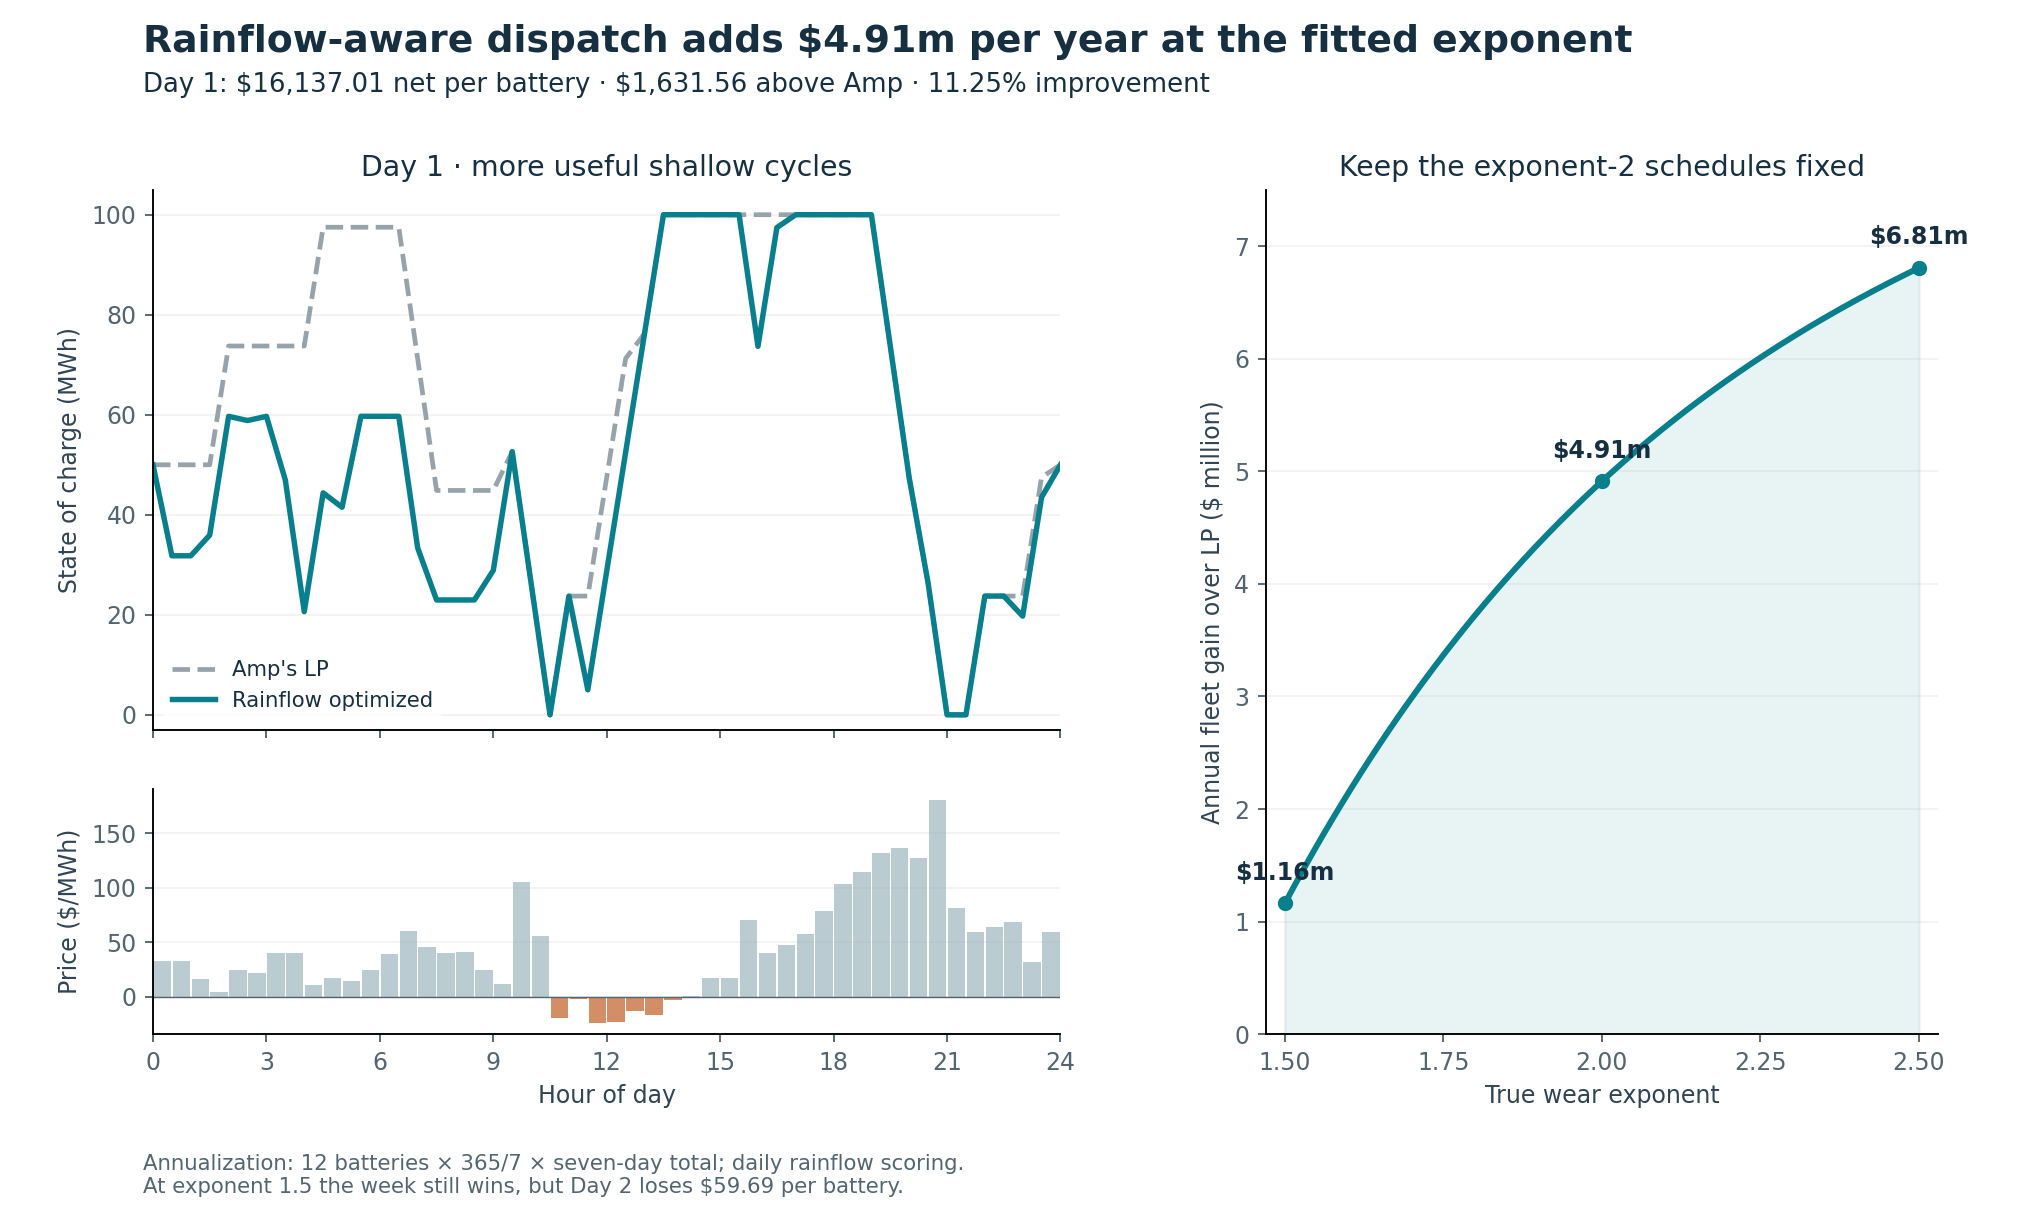

In [ ]:
# Static figure generated from the stored schedules and the original scoring functions.